In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

In [2]:
titanic_df = pd.read_csv('data/titanic_cleaned.csv', index_col='PassengerId')

# Standaryzacja danych
Przed StandardScaler() trzeba podzielić dane na train i test, aby zapobiec przeciekowi danych

In [3]:
titanic_df['Fare'] = np.log1p(titanic_df['Fare'])

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

y = titanic_df['Survived']
X = titanic_df.drop(['Survived'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, shuffle=True, random_state=8)
scaler = StandardScaler()
X_train[['Fare', 'Age']] = scaler.fit_transform(X_train[['Fare', 'Age']])
X_test[['Fare', 'Age']] = scaler.transform(X_test[['Fare', 'Age']])

In [5]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
769,3,0,-0.147239,1,0,0.269444,2,0,0,1,0
388,2,1,0.462262,0,0,-0.344032,1,1,0,0,1
824,3,1,-0.223427,0,1,-0.384059,2,0,0,0,1
779,3,0,-0.147239,0,0,-0.837738,1,1,0,1,0
158,3,0,0.005136,0,0,-0.800937,1,1,0,0,1


# Dataset balance

In [6]:
grouped = titanic_df.groupby('Survived').size()
total = titanic_df.shape[0]
percent_dead = grouped[0]/total * 100
percent_alive = 100 - percent_dead
print("Percent of survivors: ", round(percent_alive,2), "%")
print("Percent of non-survivors: ", round(percent_dead,2), "%")

Percent of survivors:  38.38 %
Percent of non-survivors:  61.62 %


# Creating baseline dummy
### Using strategy=stratified because the dataset is imbalanced and this will create a more accurate Dummy representation. It is also harder to beat the score (challenge for me)

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier


model = DummyClassifier(strategy = 'stratified')
model.fit(X_train, y_train) # uczenie
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.52      0.53       108
           1       0.30      0.31      0.30        71

    accuracy                           0.44       179
   macro avg       0.42      0.41      0.41       179
weighted avg       0.44      0.44      0.44       179

[[56 52]
 [49 22]]


# SVM
Training of the model with default parameters

In [8]:
from sklearn.svm import SVC

clf = SVC()
clf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Inferring on test data
Model is doing qute good with accuracy around 0.81. It performs worse on class '1', probably because there were fewer examples of this class in the dataset.


In [9]:
y_pred_clf = clf.predict(X_test)
print(classification_report(y_test, y_pred_clf))
print(confusion_matrix(y_test, y_pred_clf))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       108
           1       0.75      0.68      0.71        71

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179

[[92 16]
 [23 48]]


### Inferring on train data
Model is doing slightly better with train data. 0.81 accuracy on new data and 0.83 accuracy on already seen data means there's no overfitting. Model generalizes well.

In [10]:
y_pred_on_train = clf.predict(X_train)
print(classification_report(y_train, y_pred_on_train))
print(confusion_matrix(y_train, y_pred_on_train))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       441
           1       0.83      0.72      0.77       271

    accuracy                           0.84       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.84      0.83       712

[[400  41]
 [ 76 195]]


### Hyperparameter tuning

In [11]:
param_grid = {
    'C' : [0.1,1,10,100,1000],
    'gamma' : [1, 0.1, 0.01, 0.001, 0.0001],
    'class_weight' : [None, 'balanced'] # since dataset is a little bit unbalanced
}

In [12]:
grid = GridSearchCV(SVC(), param_grid=param_grid, verbose=3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END .C=0.1, class_weight=None, gamma=1;, score=0.622 total time=   0.0s
[CV 2/5] END .C=0.1, class_weight=None, gamma=1;, score=0.636 total time=   0.0s
[CV 3/5] END .C=0.1, class_weight=None, gamma=1;, score=0.620 total time=   0.0s
[CV 4/5] END .C=0.1, class_weight=None, gamma=1;, score=0.641 total time=   0.0s
[CV 5/5] END .C=0.1, class_weight=None, gamma=1;, score=0.620 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.790 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.776 total time=   0.0s
[CV 3/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.810 total time=   0.0s
[CV 4/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.775 total time=   0.0s
[CV 5/5] END C=0.1, class_weight=None, gamma=0.1;, score=0.789 total time=   0.0s
[CV 1/5] END C=0.1, class_weight=None, gamma=0.01;, score=0.622 total time=   0.0s
[CV 2/5] END C=0.1, class_weight=None, g

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': [1, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


The best hyperparameters: C=1, gamma=0.1, class_weight=None

In [13]:
clf_tuned = grid.best_estimator_
clf_tuned.fit(X_train, y_train)
y_pred_tuned = clf_tuned.predict(X_test)
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       108
           1       0.75      0.68      0.71        71

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179

[[92 16]
 [23 48]]


### Visualisation

In [14]:
results = []
for i in param_grid['C']:
    for j in param_grid['gamma']:
        model = SVC(C=i, gamma=j)
        model.fit(X_train,y_train)
        y_predd = model.predict(X_test)
        score = f1_score(y_test, y_predd)
        results.append([i, j, score])


In [15]:
results = np.array(results)
results = pd.DataFrame(results, columns=['C', 'gamma', 'f1'])

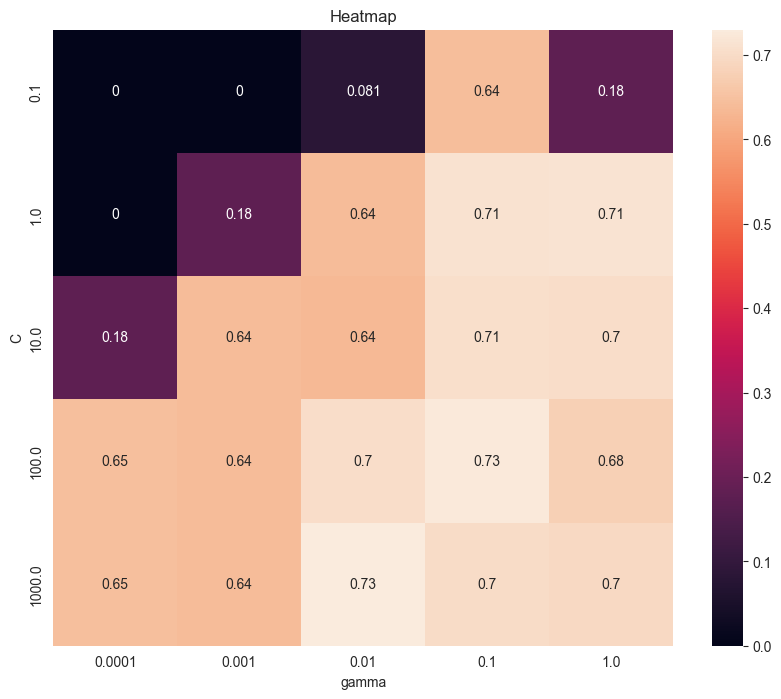

In [16]:
results = results.pivot(index='C', columns='gamma', values='f1')
plt.figure(figsize=(10, 8))
sns.heatmap(results,annot=True)
plt.title('Heatmap')
plt.show()

### Summary of SVC
Performance is better than Dummy Classifier, accuracy unfortunately under 80%. Hyperparameter tuning in this case improved nothing, or so little that it's not visible.
# Decision Tree

In [17]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Inferring on train data

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       108
           1       0.72      0.73      0.73        71

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

[[88 20]
 [19 52]]


[Text(0.5126845018450185, 0.9736842105263158, 'Sex <= 0.5\ngini = 0.471\nsamples = 712\nvalue = [441, 271]'),
 Text(0.21817343173431733, 0.9210526315789473, 'Pclass <= 1.5\ngini = 0.29\nsamples = 460\nvalue = [379, 81]'),
 Text(0.3654289667896679, 0.9473684210526316, 'True  '),
 Text(0.08302583025830258, 0.868421052631579, 'Age <= 1.757\ngini = 0.463\nsamples = 99\nvalue = [63, 36]'),
 Text(0.055350553505535055, 0.8157894736842105, 'Fare <= 0.348\ngini = 0.491\nsamples = 81\nvalue = [46, 35]'),
 Text(0.02214022140221402, 0.7631578947368421, 'FamilySize <= 3.0\ngini = 0.332\nsamples = 19\nvalue = [15, 4]'),
 Text(0.014760147601476014, 0.7105263157894737, 'Age <= 0.272\ngini = 0.278\nsamples = 18\nvalue = [15, 3]'),
 Text(0.007380073800738007, 0.6578947368421053, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.02214022140221402, 0.6578947368421053, 'Age <= 0.386\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.014760147601476014, 0.6052631578947368, 'gini = 0.0\nsamples = 1\nva

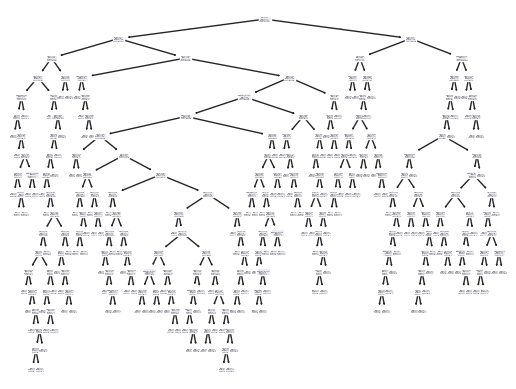

In [18]:
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))
from sklearn import tree
tree.plot_tree(model,feature_names=list(X_test.columns))

### Inferring on test data
There is overfitting occurring in the model. Inferring on test data showed 0.76 accuracy, while inferring on train data is 0.98. The trees are very deep, so let's assign max_depth=3

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       441
           1       1.00      0.95      0.97       271

    accuracy                           0.98       712
   macro avg       0.98      0.97      0.98       712
weighted avg       0.98      0.98      0.98       712

[[440   1]
 [ 14 257]]


[Text(0.5126845018450185, 0.9736842105263158, 'Sex <= 0.5\ngini = 0.471\nsamples = 712\nvalue = [441, 271]'),
 Text(0.21817343173431733, 0.9210526315789473, 'Pclass <= 1.5\ngini = 0.29\nsamples = 460\nvalue = [379, 81]'),
 Text(0.3654289667896679, 0.9473684210526316, 'True  '),
 Text(0.08302583025830258, 0.868421052631579, 'Age <= 1.757\ngini = 0.463\nsamples = 99\nvalue = [63, 36]'),
 Text(0.055350553505535055, 0.8157894736842105, 'Fare <= 0.348\ngini = 0.491\nsamples = 81\nvalue = [46, 35]'),
 Text(0.02214022140221402, 0.7631578947368421, 'FamilySize <= 3.0\ngini = 0.332\nsamples = 19\nvalue = [15, 4]'),
 Text(0.014760147601476014, 0.7105263157894737, 'Age <= 0.272\ngini = 0.278\nsamples = 18\nvalue = [15, 3]'),
 Text(0.007380073800738007, 0.6578947368421053, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.02214022140221402, 0.6578947368421053, 'Age <= 0.386\ngini = 0.397\nsamples = 11\nvalue = [8, 3]'),
 Text(0.014760147601476014, 0.6052631578947368, 'gini = 0.0\nsamples = 1\nva

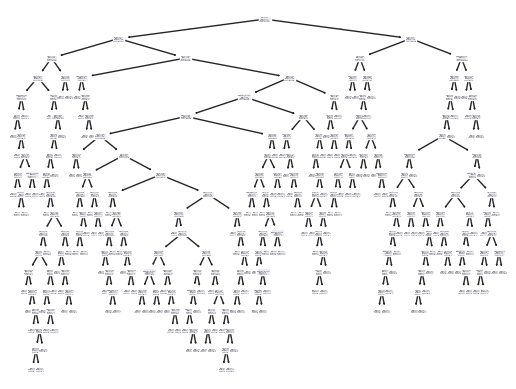

In [19]:
y_pred = model.predict(X_train)
print(classification_report(y_train,y_pred))
print(confusion_matrix(y_train, y_pred))
tree.plot_tree(model,feature_names=list(X_test.columns))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       108
           1       0.72      0.66      0.69        71

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



[Text(0.5, 0.875, 'x[1] <= 0.5\ngini = 0.471\nsamples = 712\nvalue = [441, 271]'),
 Text(0.25, 0.625, 'x[0] <= 1.5\ngini = 0.29\nsamples = 460\nvalue = [379, 81]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[2] <= 1.757\ngini = 0.463\nsamples = 99\nvalue = [63, 36]'),
 Text(0.0625, 0.125, 'gini = 0.491\nsamples = 81\nvalue = [46, 35]'),
 Text(0.1875, 0.125, 'gini = 0.105\nsamples = 18\nvalue = [17, 1]'),
 Text(0.375, 0.375, 'x[2] <= -1.785\ngini = 0.218\nsamples = 361\nvalue = [316, 45]'),
 Text(0.3125, 0.125, 'gini = 0.48\nsamples = 15\nvalue = [6, 9]'),
 Text(0.4375, 0.125, 'gini = 0.186\nsamples = 346\nvalue = [310, 36]'),
 Text(0.75, 0.625, 'x[0] <= 2.5\ngini = 0.371\nsamples = 252\nvalue = [62, 190]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[2] <= -2.09\ngini = 0.094\nsamples = 141\nvalue = [7, 134]'),
 Text(0.5625, 0.125, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6875, 0.125, 'gini = 0.083\nsamples = 139\nvalue = [6, 133]'),
 Text(0.875, 0.375, '

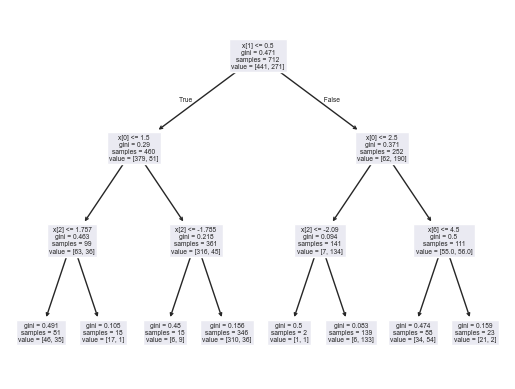

In [20]:
model = DecisionTreeClassifier(max_depth=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
tree.plot_tree(model)

In [21]:
y_pred = model.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       441
           1       0.81      0.72      0.76       271

    accuracy                           0.83       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.83      0.83       712



With max_depth=3 I got rid of overfitting, but the overall performance is still better with train data (it is to be expected).
The performance can be improved with hyperparameter tuning.

In [22]:
param_grid = {
    'max_depth' : range(1,10),
    'min_samples_leaf': range(1, 20, 2),
    'min_samples_split': range(2, 20, 2),
    'criterion' : ['gini', 'entropy', 'log_loss'],
}

In [23]:
grid = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid, verbose=3)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 2430 candidates, totalling 12150 fits
[CV 1/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.839 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.741 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.838 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.782 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=2;, score=0.796 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.839 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.741 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=1, min_samples_leaf=1, min_samples_split=4;, score=0.838 total time=   0.0s
[CV 4/5] END c

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': range(1, 10), 'min_samples_leaf': range(1, 20, 2), 'min_samples_split': range(2, 20, 2)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [25]:
model = grid.best_estimator_
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       108
           1       0.72      0.66      0.69        71

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179

